# Vortex Induced Vibrations


In [25]:
import numpy as np
import matplotlib.pyplot as plt


L = 50.0
D = 0.5
rho_w = 1025
rho_c = 7880
T = 30000
b = 126
St = 0.21

A_cross = np.pi * D**2 / 4
m = rho_c * A_cross * L
m_a = rho_w * A_cross * L
m_eff = m + m_a
omega_n = (np.pi / L) * np.sqrt(T / m_eff)
zeta = b / (2 * omega_n * m_eff)

epsilon = 0.3
A_coupling = 20.0
Cx0_hat = 1.0
Cy1_hat = 0.3
q1_hat = 1.0


In [26]:
def rhs(t, x, U):

    q = x[0]
    q_dot = x[1]
    y = x[2]
    y_dot = x[3]

    # Lift 
    Lift = 0.5 * rho_w * U**2 * D * L * q

    # Structural 
    y_ddot = (-2*zeta*omega_n*y_dot - omega_n**2*y + Lift/m_eff)

    # Wake 
    q_ddot = (-epsilon*(q**2 - 1)*q_dot - q + A_coupling*y_ddot)

    return np.array([q_dot, q_ddot, y_dot, y_ddot])

In [27]:
def rk4(f, t, x, dt, U):

    k1 = f(t, x, U)
    k2 = f(t + dt/2, x + dt/2 * k1, U)
    k3 = f(t + dt/2, x + dt/2 * k2, U)
    k4 = f(t + dt, x + dt * k3, U)

    return x + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

In [28]:
def comp_x(dt, t_end, U):
    time = np.arange(0, t_end, dt)
    x = np.array([0.01, 0.0, 0.0, 0.0])
    solution = np.zeros((len(time), 4))

    for i, t in enumerate(time):
        solution[i] = x
        x = rk4(rhs, t, x, dt, U)

    return time, solution

In [29]:
def compute_amplitude(U):

    time, solution = comp_x(dt , t_end, U)

    y = solution[:,2]

    # Remove transient (last 30%)
    cutoff = int(0.7 * len(y))
    y_steady = y[cutoff:]

    amplitude = 0.5*(np.max(y_steady) - np.min(y_steady))

    return amplitude

In [30]:
def simulate_velocity(dt, t_end, U):

    time, solution = comp_x(dt, t_end, U)

    y = solution[:, 2]   # midpoint displacement

    # Remove transient
    cutoff = int(0.7 * len(y))
    y_steady = y[cutoff:]

    amplitude = 0.5 * (np.max(y_steady) - np.min(y_steady))

    return amplitude

Amplitude for U=0.03 m/s: 0.28 mm
Amplitude for U=0.09 m/s: 2.54 mm
Amplitude for U=0.15 m/s: 7.38 mm
Amplitude for U=0.21 m/s: 15.47 mm
Amplitude for U=0.27 m/s: 28.21 mm
Simulation completed in 3.65 seconds.


<Figure size 1200x800 with 0 Axes>

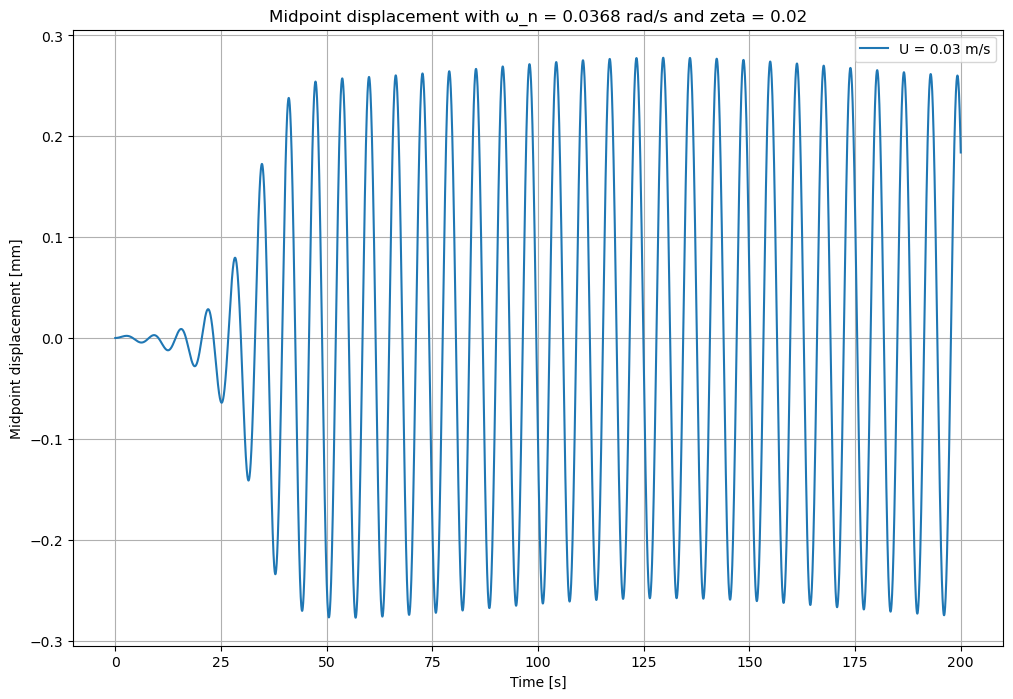

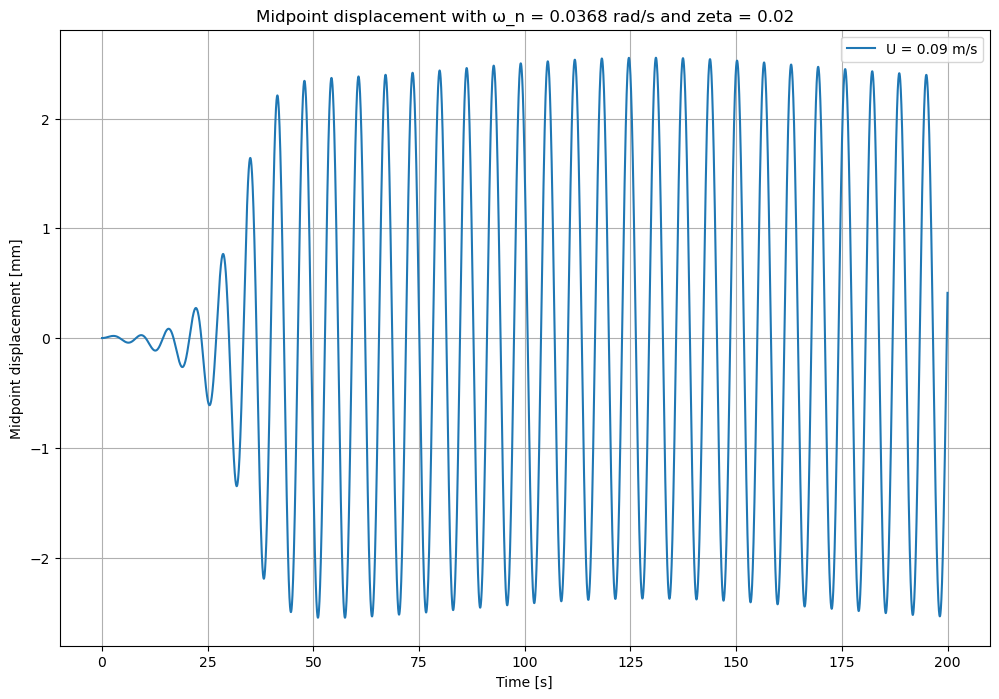

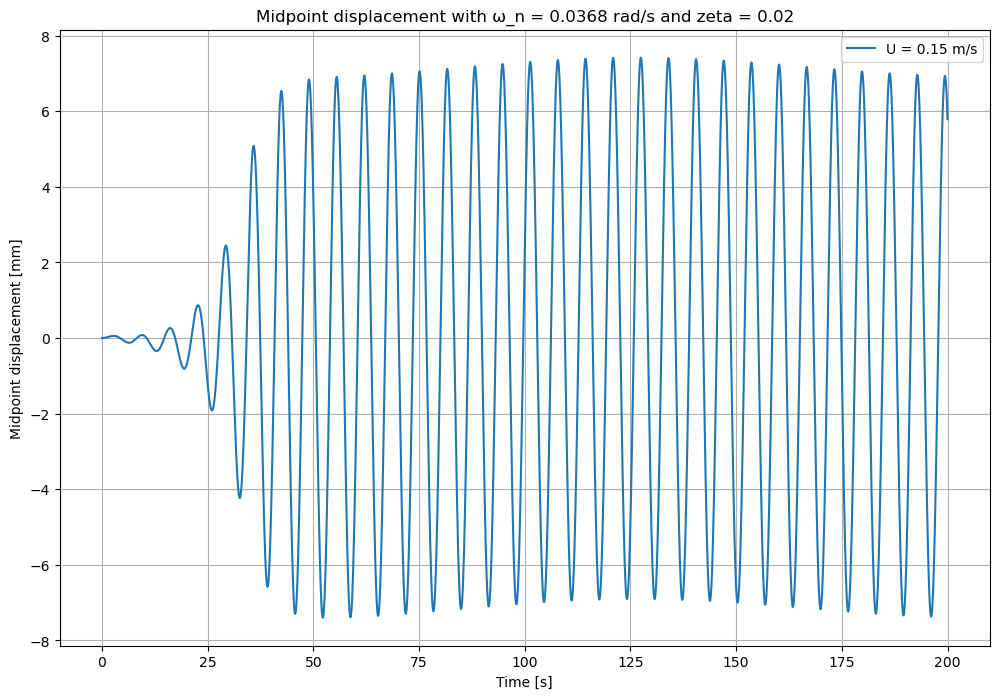

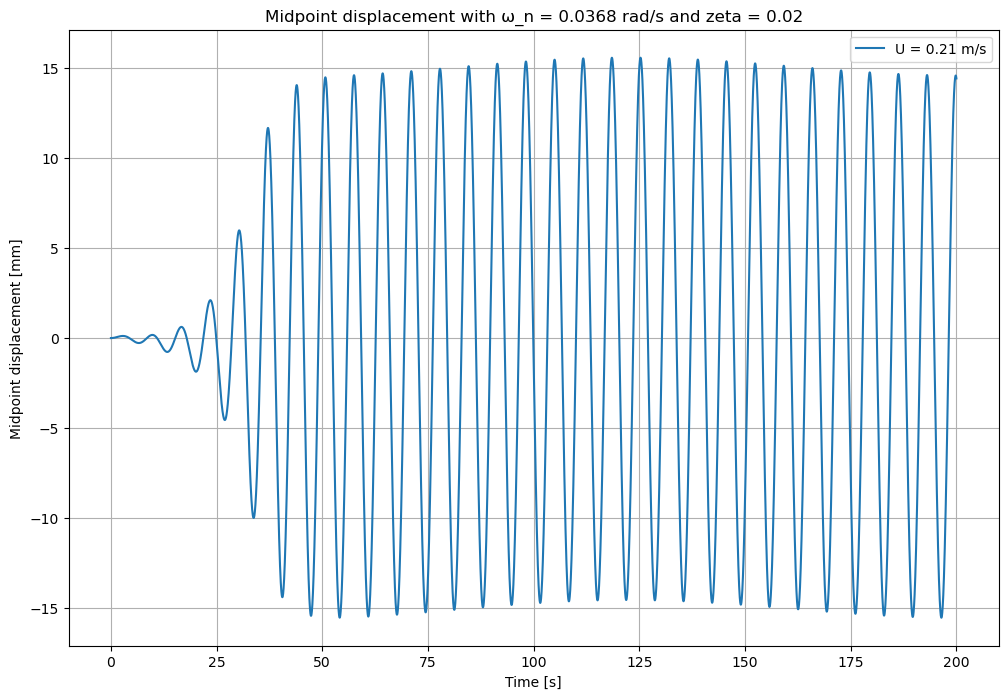

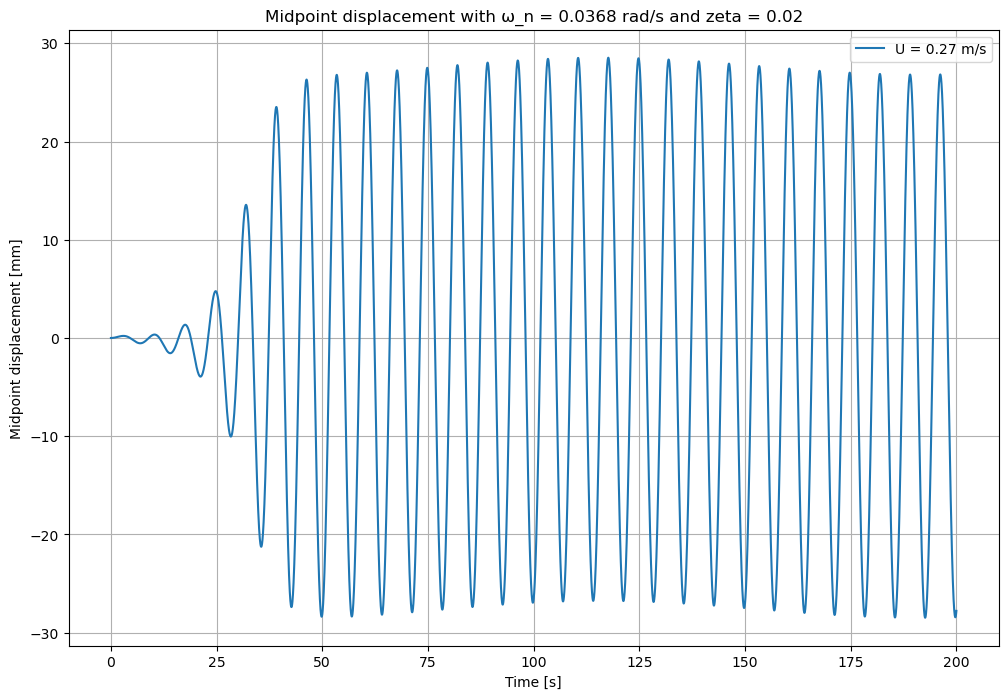

In [31]:
U_range = np.linspace(0.03, 0.27, 5)

plt.figure(figsize=(12,8))
import time as td
start_time = td.time()

for U in U_range:
    dt = 0.01
    t_end = 200
    time, solution = comp_x(dt, t_end, U)
    plt.figure(figsize=(12,8))
    plt.plot(time, 1000* solution[:,2], label=f"U = {U:.2f} m/s")
    plt.xlabel("Time [s]")
    plt.title(f"Midpoint displacement with \u03C9_n = {omega_n:.4f} rad/s and zeta = {zeta:.2f}")
    plt.ylabel("Midpoint displacement [mm]")
    plt.legend()
    plt.grid()

    print(f"Amplitude for U={U:.2f} m/s: {compute_amplitude(U)*1000:.2f} mm")

end_time = td.time()
print(f"Simulation completed in {end_time - start_time:.2f} seconds.")


Solving for U = 0.030
Solving for U = 0.090
Solving for U = 0.150
Solving for U = 0.210
Solving for U = 0.270


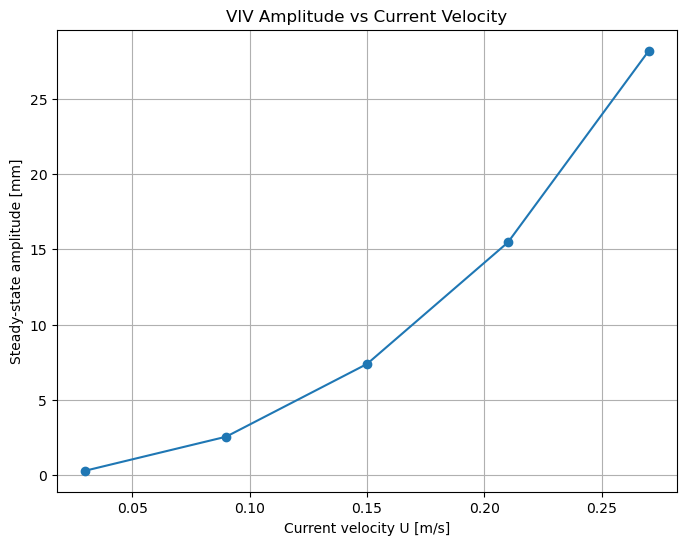

In [32]:
U_values = np.linspace(0.03, 0.27, 5)
amplitudes = []

for U in U_values:
    print(f"Solving for U = {U:.3f}")
    amp = compute_amplitude(U)
    amplitudes.append(amp)

plt.figure(figsize=(8,6))
plt.plot(U_values, 1000 * np.array(amplitudes), marker='o')
plt.xlabel("Current velocity U [m/s]")
plt.ylabel("Steady-state amplitude [mm]")
plt.title("VIV Amplitude vs Current Velocity")
plt.grid(True)


Amplitude for U=0.03 m/s: 0.28 mm
Amplitude for U=0.09 m/s: 2.54 mm
Amplitude for U=0.15 m/s: 7.38 mm
Amplitude for U=0.21 m/s: 15.47 mm
Amplitude for U=0.27 m/s: 28.21 mm
Simulation completed in 3.37 seconds.


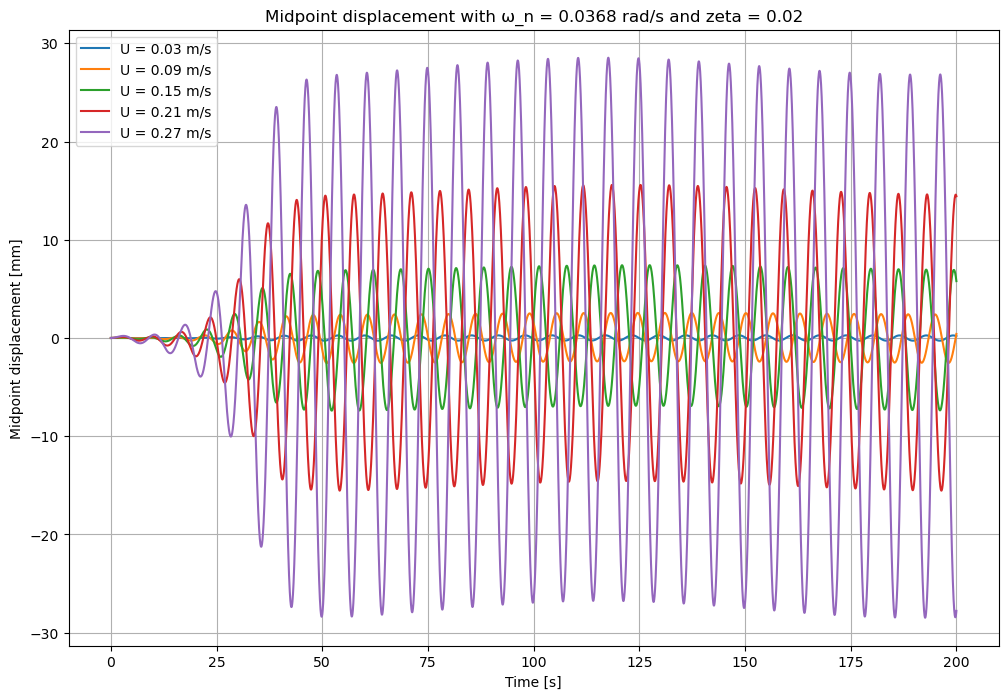

In [33]:
U_range = np.linspace(0.03, 0.27, 5)

plt.figure(figsize=(12,8))
import time as td
start_time = td.time()

for U in U_range:
    dt = 0.01
    t_end = 200
    time, solution = comp_x(dt, t_end, U)
    plt.plot(time, 1000* solution[:,2], label=f"U = {U:.2f} m/s")
    print(f"Amplitude for U={U:.2f} m/s: {compute_amplitude(U)*1000:.2f} mm")

plt.xlabel("Time [s]")
plt.title(f"Midpoint displacement with \u03C9_n = {omega_n:.4f} rad/s and zeta = {zeta:.2f}")
plt.ylabel("Midpoint displacement [mm]")
plt.legend()
plt.grid()


end_time = td.time()
print(f"Simulation completed in {end_time - start_time:.2f} seconds.")